# Carga de librerías base (Pandas, Numpy) y de Machine Learning (Scikit-Learn, XGBoost) necesarias para todo el pipeline.

In [1]:
import numpy as np
import pandas as pd
import os
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

# Conexión con Google Drive y lectura de los archivos CSV originales (aug_train y aug_test).

In [3]:
aug_train=pd.read_csv('/content/drive/MyDrive/Project_HR/csv/aug_train.csv')
aug_test=pd.read_csv('/content/drive/MyDrive/Project_HR/csv/aug_test.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Uso de .head(), .info() y .describe() para entender los tipos de datos, ver las primeras filas y obtener estadísticas básicas.

In [5]:
aug_train.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [6]:
aug_test.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72
5,217,city_23,0.899,Male,No relevent experience,Part time course,Masters,STEM,10,NaN,NaN,2,12
6,21465,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,STEM,<1,100-500,Pvt Ltd,1,11
7,27302,city_160,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,>4,81
8,12994,city_173,0.878,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,2
9,16287,city_21,0.624,Male,Has relevent experience,Full time course,Graduate,NaN,3,50-99,Funded Startup,1,4


In [7]:
aug_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [8]:
aug_test.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [9]:
aug_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [10]:
aug_train.describe

<bound method NDFrame.describe of        enrollee_id      city  city_development_index gender  \
0             8949  city_103                   0.920   Male   
1            29725   city_40                   0.776   Male   
2            11561   city_21                   0.624    NaN   
3            33241  city_115                   0.789    NaN   
4              666  city_162                   0.767   Male   
...            ...       ...                     ...    ...   
19153         7386  city_173                   0.878   Male   
19154        31398  city_103                   0.920   Male   
19155        24576  city_103                   0.920   Male   
19156         5756   city_65                   0.802   Male   
19157        23834   city_67                   0.855    NaN   

           relevent_experience enrolled_university education_level  \
0      Has relevent experience       no_enrollment        Graduate   
1       No relevent experience       no_enrollment        Graduate   
2       No relevent experience    Full time course        Graduate   
3       No relevent experience                 NaN        Graduate   
4      Has relevent experience       no_enrollment         Masters   
...                        ...                 ...             ...   
19153   No relevent experience       no_enrollment        Graduate   
19154  Has relevent experience       no_enrollment        Graduate   
19155  Has relevent experience       no_enrollment        Graduate   
19156  Has relevent experience       no_enrollment     High School   
19157   No relevent experience       no_enrollment  Primary School   

      major_discipline experience company_size    company_type last_new_job  \
0                 STEM        >20          NaN             NaN            1   
1                 STEM         15        50-99         Pvt Ltd           >4   
2                 STEM          5          NaN             NaN        never   
3      Business Degree         <1          NaN         Pvt Ltd        never   
4                 STEM        >20        50-99  Funded Startup            4   
...                ...        ...          ...             ...          ...   
19153       Humanities         14          NaN             NaN            1   
19154             STEM         14          NaN             NaN            4   
19155             STEM        >20        50-99         Pvt Ltd            4   
19156              NaN         <1      500-999         Pvt Ltd            2   
19157              NaN          2          NaN             NaN            1   

       training_hours  target  
0                  36     1.0  
1                  47     0.0  
2                  83     0.0  
3                  52     1.0  
4                   8     0.0  
...               ...     ...  
19153              42     1.0  
19154              52     1.0  
19155              44     0.0  
19156              97     0.0  
19157             127     0.0  

[19158 rows x 14 columns]>

# Cálculo del porcentaje de valores faltantes por columna para decidir la estrategia de limpieza posterior.

In [11]:
percent_missing = aug_train.isnull().sum() * 100 / len(aug_train)
missing_value_df = pd.DataFrame({#'column_name': train.columns,
                                 'percent_missing': percent_missing})
percent_missing

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [12]:
percent_missing = aug_test.isnull().sum() * 100 / len(aug_test)
missing_value_df = pd.DataFrame({#'column_name': train.columns,
                                 'percent_missing': percent_missing})
percent_missing

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,23.860968
relevent_experience,0.000000
enrolled_university,1.456083
education_level,2.442461
major_discipline,14.654767
experience,0.234852
company_size,29.215594


# Uso de la librería missingno para ver gráficamente dónde se concentran los datos faltantes.

<Axes: >

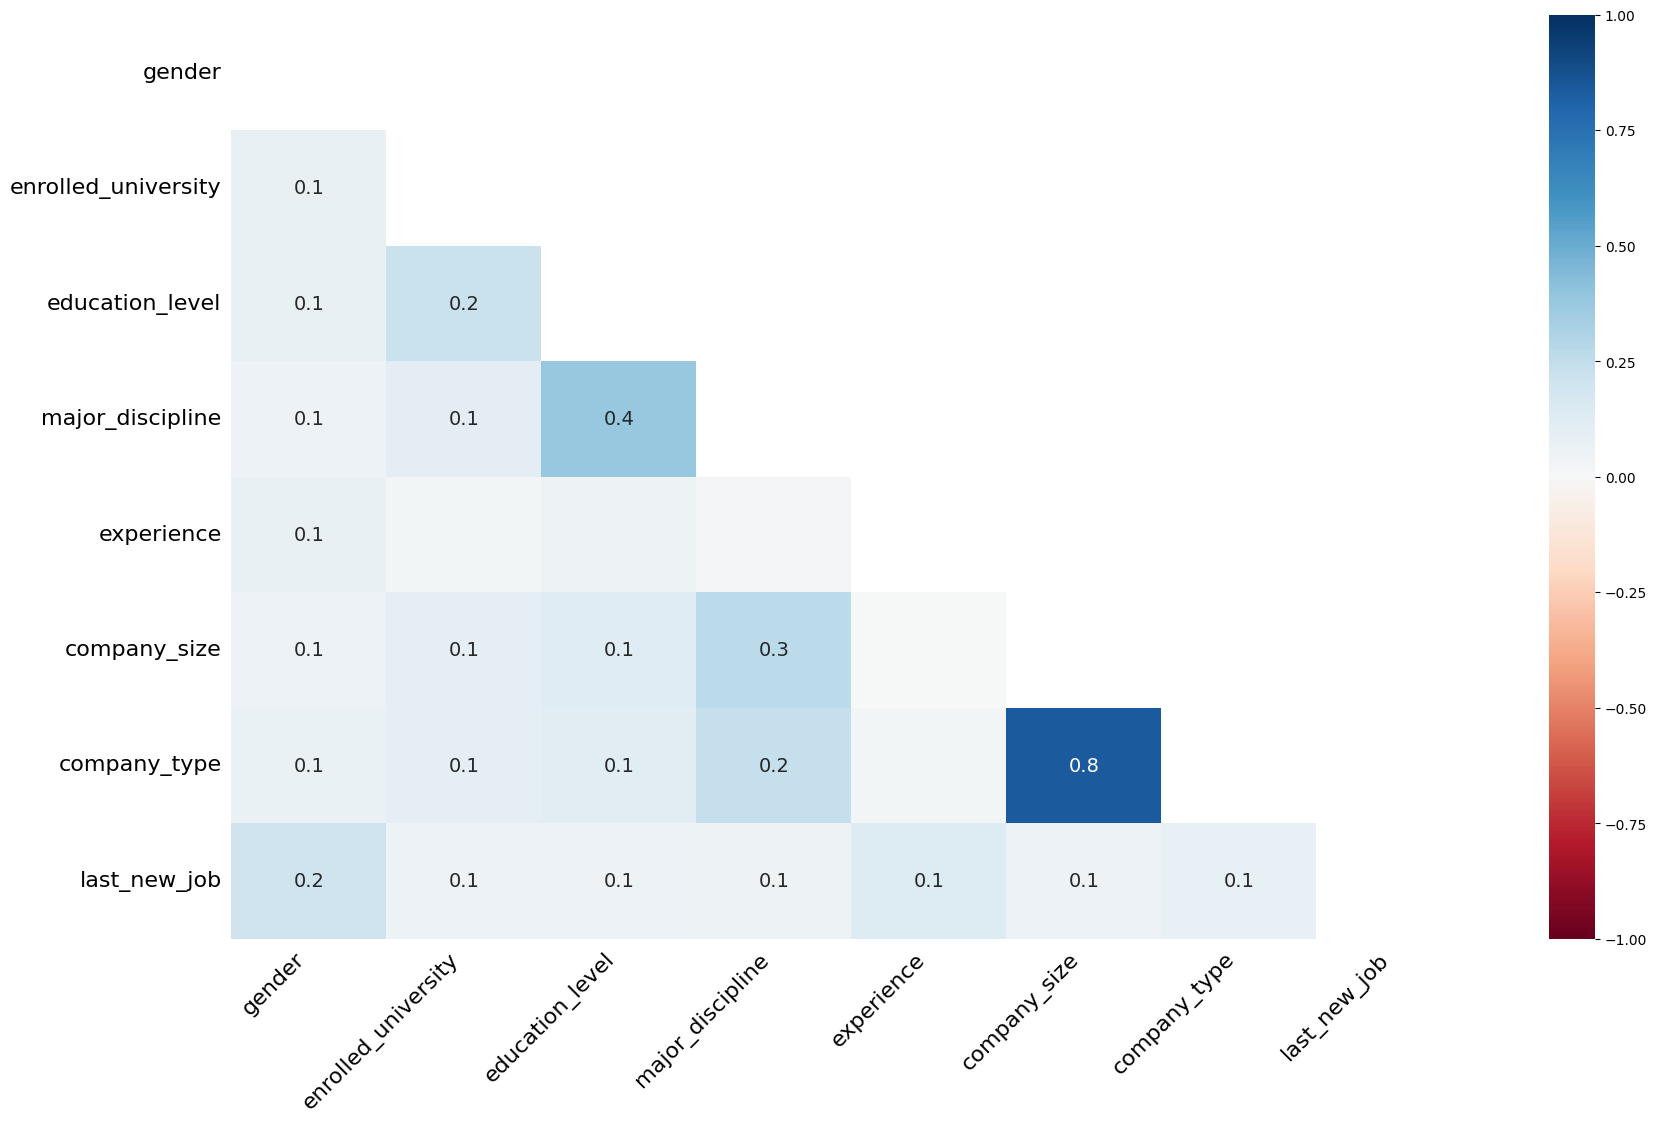

In [13]:
msno.heatmap(aug_train)

<Axes: >

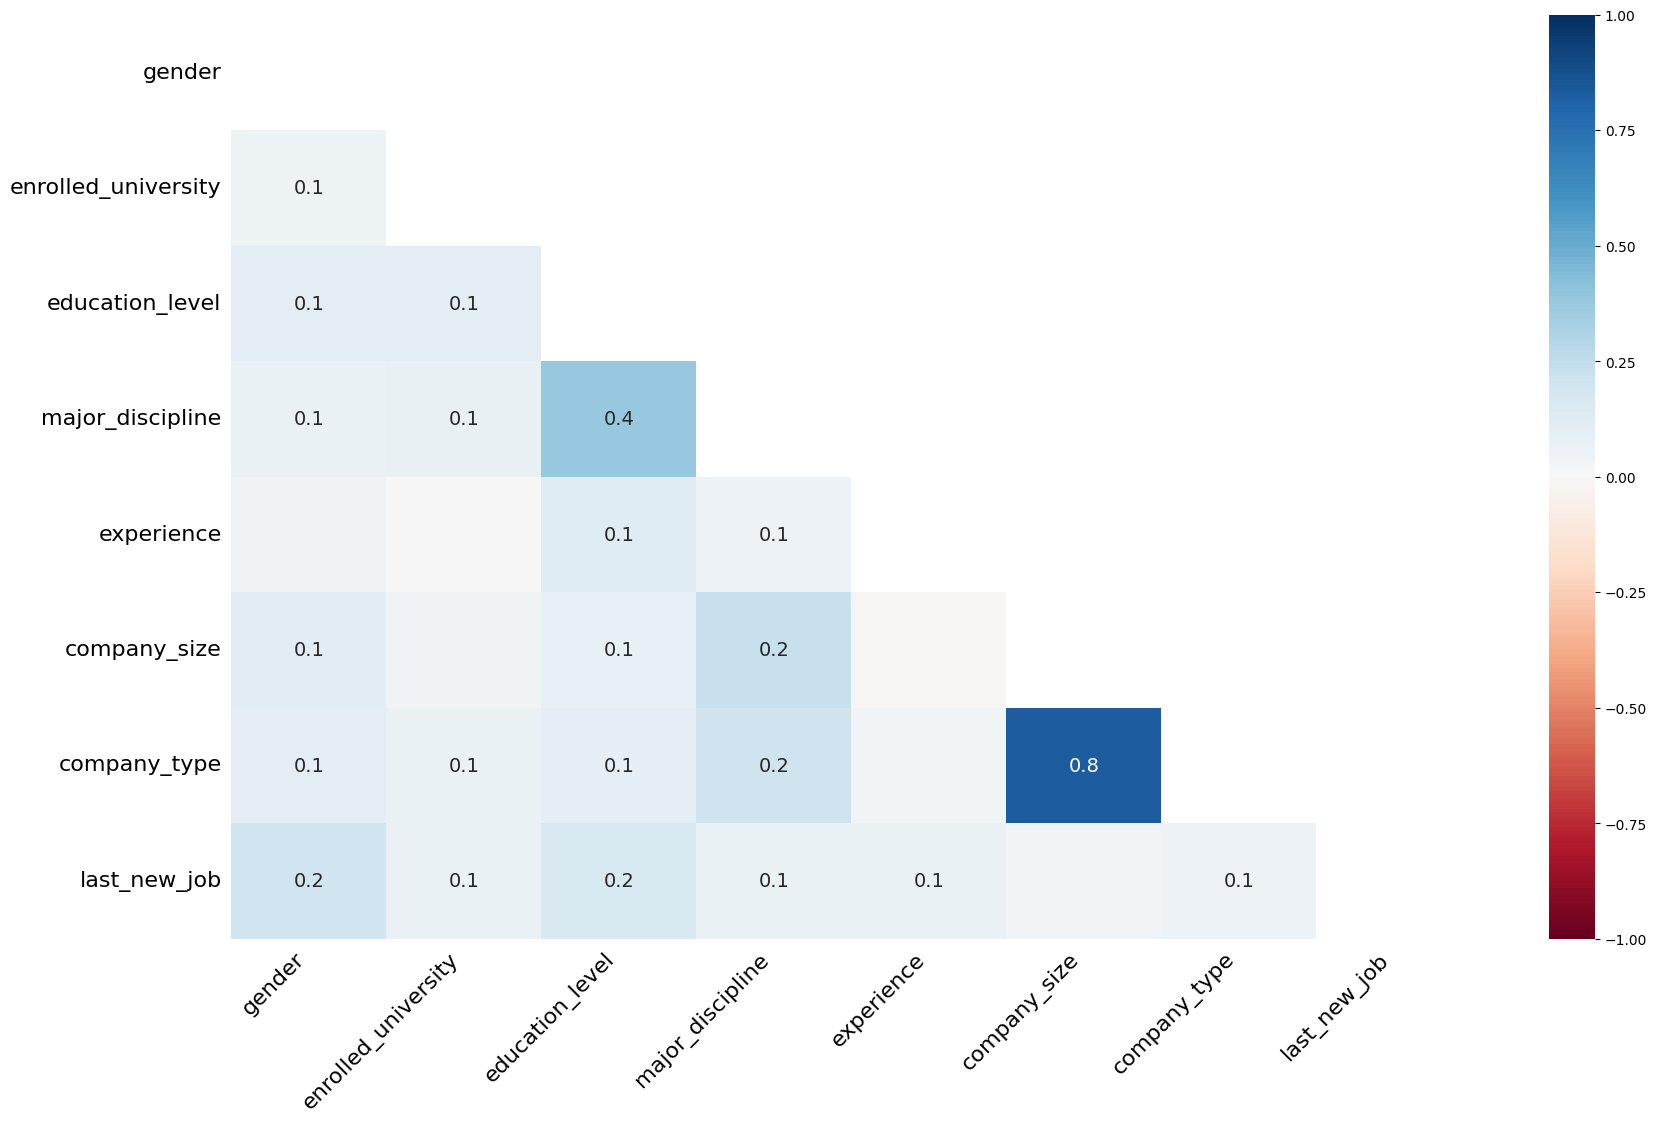

In [14]:
msno.heatmap(aug_test)

# Gráfico de tarta que muestra el desbalanceo de la clase objetivo (cuánta gente se va vs. cuánta se queda).

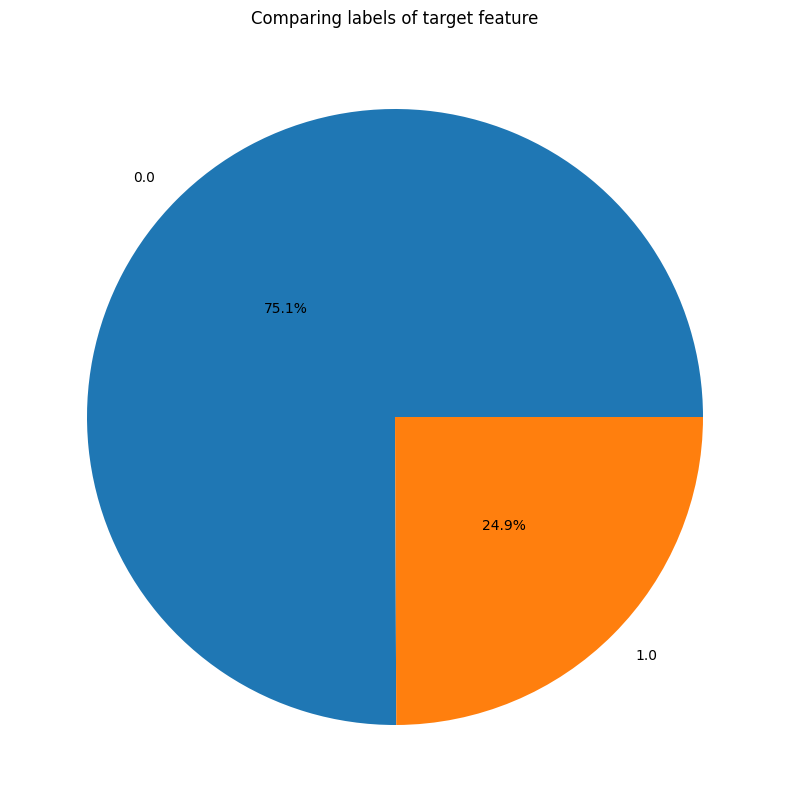

In [15]:
values = aug_train['target'].value_counts().values.tolist()
labels = aug_train['target'].value_counts().index
plt.figure(figsize= (10,10))
plt.title('Comparing labels of target feature')
plt.pie(x = values, labels = labels, autopct='%1.1f%%', pctdistance= .5)
plt.show()

# Gráficos de barras que comparan las variables de texto (género, educación, etc.) con la intención de abandonar la empresa.

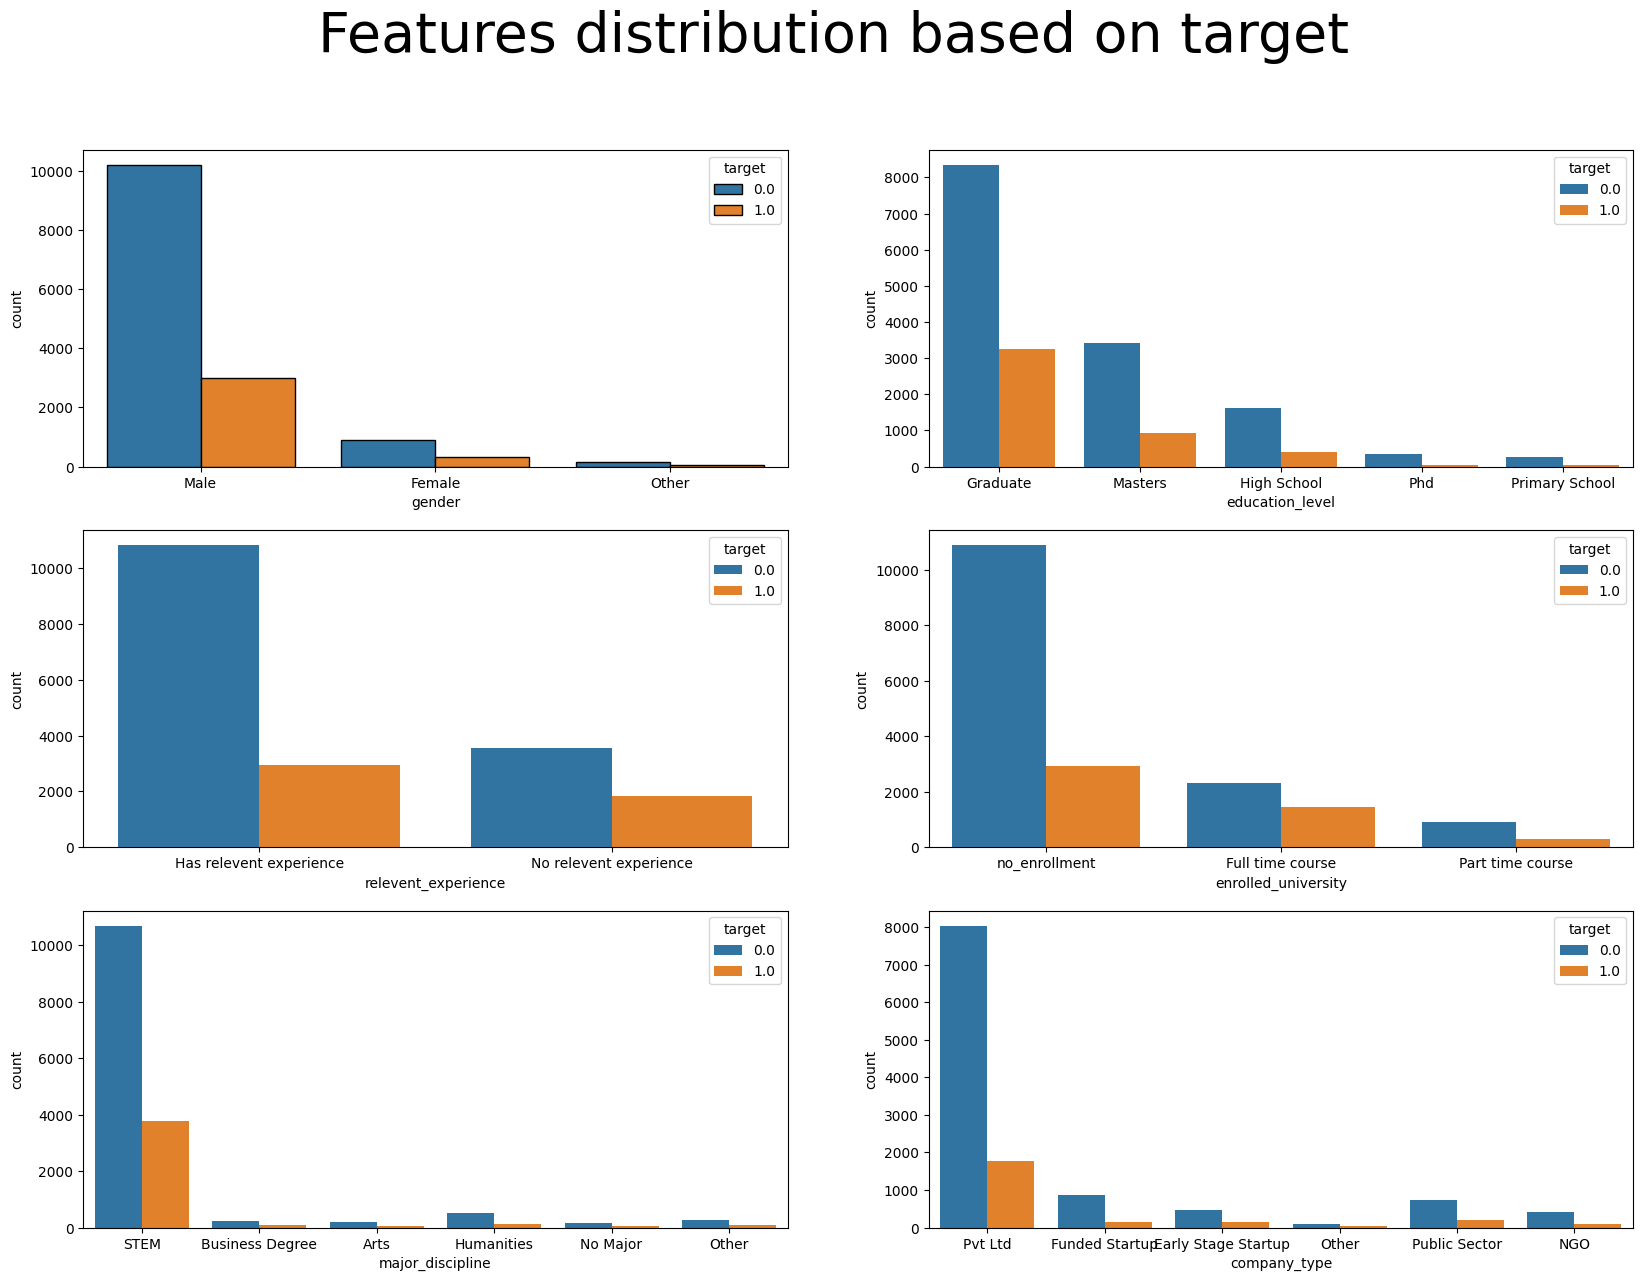

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig_dims = (20, 14)
fig, ax = plt.subplots(3, 2, figsize = fig_dims)

sns.countplot(x = aug_train['gender'], hue = aug_train['target'], ax=ax[0,0], edgecolor='black')

sns.countplot(x = aug_train['education_level'], hue = aug_train['target'], ax=ax[0,1])

sns.countplot(x = aug_train['relevent_experience'], hue = aug_train['target'], ax=ax[1,0])

sns.countplot(x = aug_train['enrolled_university'], hue = aug_train['target'], ax=ax[1,1])

sns.countplot(x = aug_train['major_discipline'], hue = aug_train['target'], ax=ax[2,0])

sns.countplot(x = aug_train['company_type'], hue = aug_train['target'], ax=ax[2,1])

fig.suptitle('Features distribution based on target', fontsize=40)
plt.show()

# Gráfico de densidad (KDE) para ver cómo influye el índice de desarrollo de la ciudad en la fuga de talento.

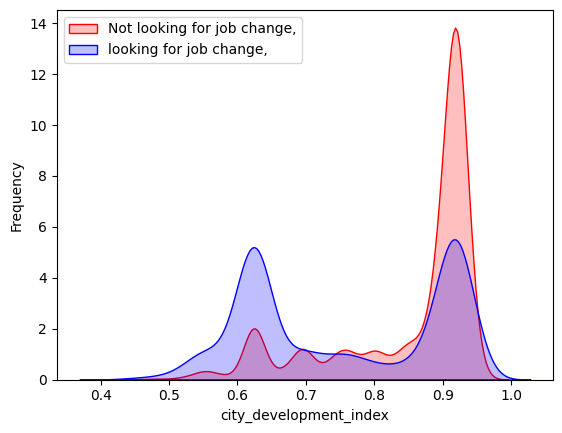

In [17]:
g = sns.kdeplot(aug_train['city_development_index'][(aug_train["target"] == 0) & (aug_train['city_development_index'].notnull())], color="Red", fill=True)
g = sns.kdeplot(aug_train['city_development_index'][(aug_train["target"] == 1) & (aug_train['city_development_index'].notnull())], ax =g, color="Blue", fill=True)
g.set_xlabel('city_development_index')
g.set_ylabel("Frequency")
g = g.legend(["Not looking for job change,","looking for job change,"])

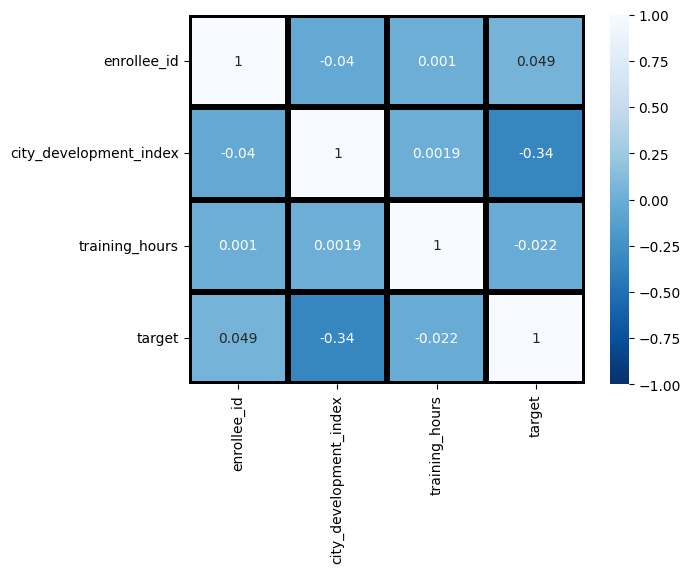

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Añadimos numeric_only=True dentro de corr()
sns.heatmap(aug_train.corr(numeric_only=True), annot = True, vmin=-1, vmax=1, center= 0,
            cmap= 'Blues_r', linewidths=3, linecolor='black')

plt.show()

# Análisis profundo cruzando género, nivel de educación y horas de formación para encontrar patrones específicos.

city_development_index  training_hours
gender target                                        
Female 0.0                   0.862836       67.020833
       1.0                   0.794117       61.763804
Male   0.0                   0.859919       65.853365
       1.0                   0.768328       63.414011
Other  0.0                   0.876745       61.680851
       1.0                   0.836740       70.040000

<Axes: xlabel='gender,target'>

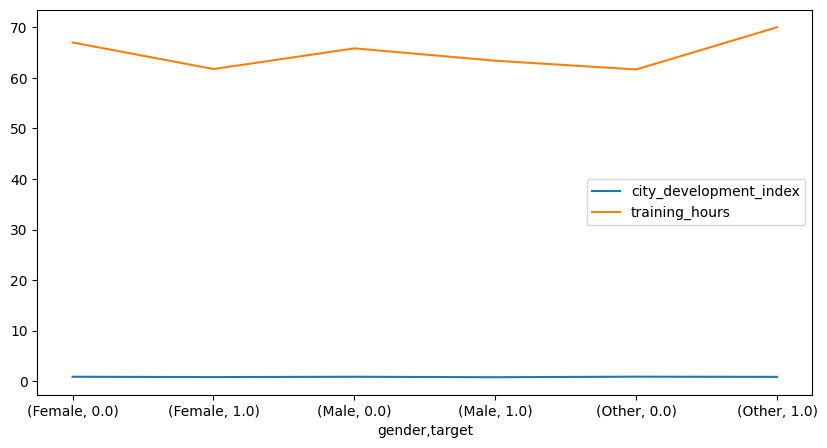

In [19]:
# Añadimos el parámetro values con las columnas numéricas que queremos analizar
table = pd.pivot_table(aug_train,
                       values=['city_development_index', 'training_hours'],
                       index=['gender','target'])

# Mostramos la tabla
display(table)

# Dibujamos el gráfico
table.plot(kind='line', figsize=(10, 5))

                               city_development_index  training_hours
gender target education_level                                        
Female 0.0    Graduate                       0.860664       68.904847
              High School                    0.849898       62.673469
              Masters                        0.867188       65.909804
              Phd                            0.891098       59.731707
              Primary School                 0.926333       20.333333
       1.0    Graduate                       0.802361       60.055556
              High School                    0.774056       67.500000
              Masters                        0.768810       61.404762
              Phd                            0.917667      113.833333
              Primary School                 0.698000       37.000000
Male   0.0    Graduate                       0.857287       66.219669
              High School                    0.857282       68.007895
              Master

<Axes: xlabel='gender,target,education_level'>

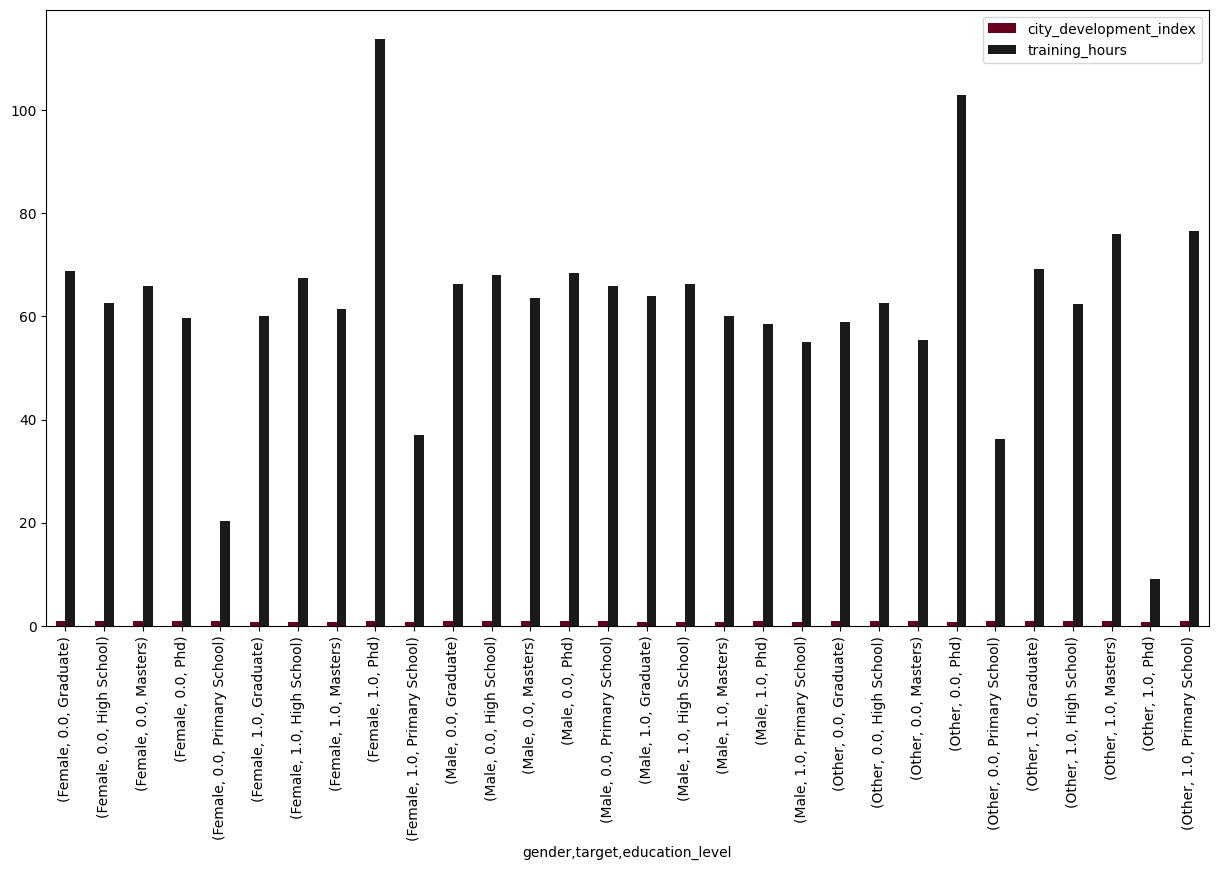

In [20]:
# Añadimos el parámetro values apuntando a las columnas numéricas
table = pd.pivot_table(aug_train,
                       values=['city_development_index', 'training_hours'],
                       index=['gender', 'target', 'education_level'])

print(table)

# Dibujamos el gráfico de barras múltiple
table.plot(kind='bar',
           figsize = (15,8),
           colormap = 'RdGy')

# **Limpieza y Preprocesamiento de Datos**

In [21]:
# LIMPIEZA Y SELECCIÓN DE COLUMNAS
df_prep = aug_train.copy() # Usamos .copy() por seguridad
# Eliminamos 'city' por tener demasiadas categorías y 'enrollee_id' que es solo un ID
df_prep.drop(['enrollee_id', 'city'], axis=1, inplace=True, errors='ignore')

# CONVERSIÓN NUMÉRICA REAL (EXPERIENCIA)
# Mapeamos los extremos y convertimos TODO a número real
exp_map = {'>20': '21', '<1': '0', 'Unknown': '-1'}
df_prep['experience'] = df_prep['experience'].replace(exp_map)
df_prep['experience'] = pd.to_numeric(df_prep['experience'], errors='coerce').fillna(-1).astype(int)

job_map = {'>4': '5', 'never': '0', 'Unknown': '-1'}
df_prep['last_new_job'] = df_prep['last_new_job'].replace(job_map)
df_prep['last_new_job'] = pd.to_numeric(df_prep['last_new_job'], errors='coerce').fillna(-1).astype(int)

# IMPUTACIÓN DE NULOS
# Rellenamos nulos en categóricas con 'Unknown' (las numéricas ya las tratamos arriba)
categorical_cols = df_prep.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_prep[col] = df_prep[col].fillna('Unknown')

# ONE-HOT ENCODING
df_final = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# Limpiamos los nombres de las columnas para XGBoost
import re
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
df_final.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in df_final.columns]

print(f"Dataset optimizado. Filas: {df_final.shape[0]}, Columnas: {df_final.shape[1]}")

Dataset optimizado. Filas: 19158, Columnas: 37


# Partición de los datos en 70% Entrenamiento, 10% Validación y 20% Test (estratificado).

In [22]:
from sklearn.model_selection import train_test_split

# Definimos X (características) y y (objetivo)
X = df_final.drop('target', axis=1)
y = df_final['target']

# Primero separamos el 20% para TEST (el "examen final")
# Del 100% total -> 20% es Test, queda 80% para (Train + Val)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ahora, del 80% restante, queremos que el 10% del TOTAL sea Validación.
# Matemáticamente, el 12.5% de ese 80% es igual al 10% del total original.
# (0.125 * 0.80 = 0.10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full
)

print(f"Muestras de Entrenamiento (70%): {X_train.shape[0]}")
print(f"Muestras de Validación (10%): {X_val.shape[0]}")
print(f"Muestras de Test (20%): {X_test.shape[0]}")

Muestras de Entrenamiento (70%): 13410
Muestras de Validación (10%): 1916
Muestras de Test (20%): 3832


# Ajuste secuencial de los 3 modelos elegidos midiendo el tiempo de ejecución de cada uno.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

# Medimos el tiempo para tu análisis
start_time = time.time()

# Definir y entrenar
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print(f"Tiempo de entrenamiento: {time.time() - start_time:.4f} segundos")

# Predecir en VALIDACIÓN
y_pred_log = log_reg.predict(X_val)

# Métricas
print("\nREPORTE: REGRESIÓN LOGÍSTICA")
print(classification_report(y_val, y_pred_log))

Tiempo de entrenamiento: 14.0569 segundos

REPORTE: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85      1438
         1.0       0.55      0.26      0.35       478

    accuracy                           0.76      1916
   macro avg       0.67      0.59      0.60      1916
weighted avg       0.73      0.76      0.73      1916



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.ensemble import RandomForestClassifier

start_time = time.time()

# Definir y entrenar
# Usamos class_weight='balanced' para compensar el desbalanceo del target
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print(f"Tiempo de entrenamiento: {time.time() - start_time:.4f} segundos")

# Predecir en VALIDACIÓN
y_pred_rf = rf_model.predict(X_val)

# Métricas
print("\nREPORTE: RANDOM FOREST")
print(classification_report(y_val, y_pred_rf))

Tiempo de entrenamiento: 1.4139 segundos

REPORTE: RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.90      0.77      0.83      1438
         1.0       0.52      0.74      0.61       478

    accuracy                           0.77      1916
   macro avg       0.71      0.76      0.72      1916
weighted avg       0.81      0.77      0.78      1916



In [25]:
import xgboost as xgb

start_time = time.time()

# Definir y entrenar
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3, # Penaliza más fallar en el target=1
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print(f"Tiempo de entrenamiento: {time.time() - start_time:.4f} segundos")

# Predecir en VALIDACIÓN
y_pred_xgb = xgb_model.predict(X_val)

# Métricas
print("\nREPORTE: XGBOOST")
print(classification_report(y_val, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:51:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tiempo de entrenamiento: 1.1260 segundos

REPORTE: XGBOOST
              precision    recall  f1-score   support

         0.0       0.90      0.79      0.84      1438
         1.0       0.53      0.73      0.62       478

    accuracy                           0.77      1916
   macro avg       0.72      0.76      0.73      1916
weighted avg       0.81      0.77      0.78      1916



# Primera evaluación para comparar métricas (F1, Recall, etc.) y decidir qué modelo parece comportarse mejor.

TABLA COMPARATIVA DE MODELOS


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.761482,0.547085,0.255230,0.348074
Random Forest,0.766180,0.521994,0.744770,0.613793
XGBoost,0.773486,0.533639,0.730126,0.616608


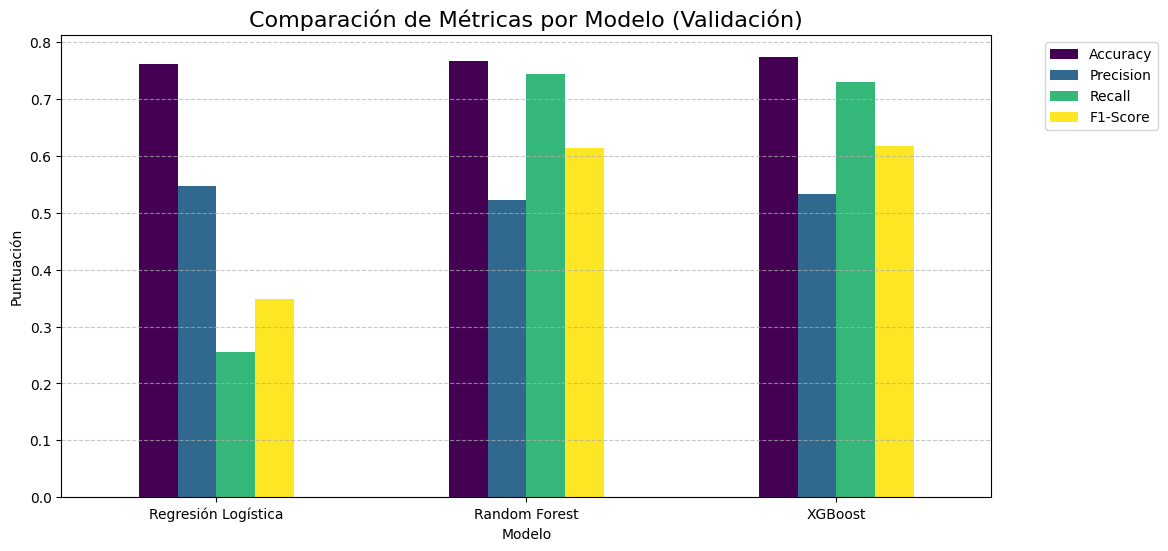

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# Creamos una función para extraer las métricas de cada modelo
def obtener_metricas(y_real, y_pred, nombre_modelo):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'F1-Score': f1_score(y_real, y_pred)
    }

# Calculamos las métricas para los tres modelos usando el conjunto de VALIDACIÓN
metricas_log = obtener_metricas(y_val, y_pred_log, 'Regresión Logística')
metricas_rf = obtener_metricas(y_val, y_pred_rf, 'Random Forest')
metricas_xgb = obtener_metricas(y_val, y_pred_xgb, 'XGBoost')

# Creamos el DataFrame comparativo
df_comparacion = pd.DataFrame([metricas_log, metricas_rf, metricas_xgb])
df_comparacion.set_index('Modelo', inplace=True)

# Mostramos la tabla
print("TABLA COMPARATIVA DE MODELOS")
display(df_comparacion)

# Gráfica de barras para comparar visualmente
df_comparacion.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparación de Métricas por Modelo (Validación)', fontsize=16)
plt.ylabel('Puntuación')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

EVALUACIÓN FINAL EN EL CONJUNTO DE TEST
              precision    recall  f1-score   support

         0.0       0.91      0.79      0.85      2877
         1.0       0.56      0.78      0.65       955

    accuracy                           0.79      3832
   macro avg       0.73      0.78      0.75      3832
weighted avg       0.82      0.79      0.80      3832



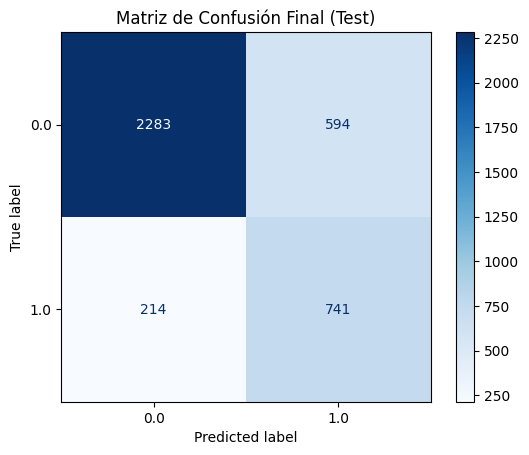

In [27]:
modelo_ganador = xgb_model

print("EVALUACIÓN FINAL EN EL CONJUNTO DE TEST")
y_final_pred = modelo_ganador.predict(X_test)

# Reporte final y Matriz de Confusión
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_final_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_final_pred, cmap='Blues')
plt.title('Matriz de Confusión Final (Test)')
plt.show()

RESULTADOS DEFINITIVOS (CONJUNTO DE TEST)


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.771399,0.581781,0.294241,0.390821
Random Forest,0.774791,0.532999,0.778010,0.632610
XGBoost,0.789144,0.555056,0.775916,0.647162


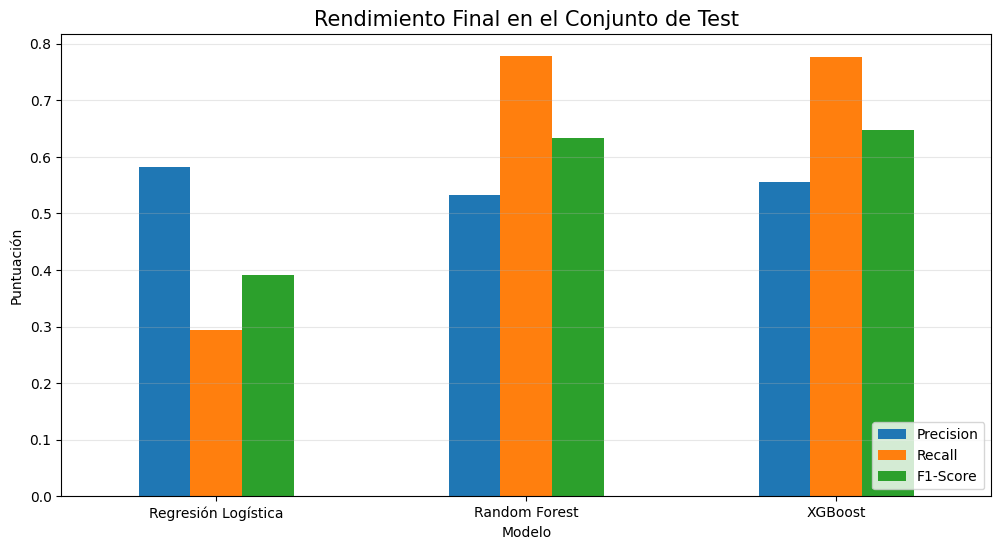

In [28]:
# EVALUACIÓN FINAL: COMPARATIVA EN TEST

# Realizamos las predicciones finales con los 3 modelos sobre el conjunto de TEST
y_test_pred_log = log_reg.predict(X_test)
y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_xgb = xgb_model.predict(X_test)

# Calculamos las métricas finales
df_test_comparativa = pd.DataFrame([
    obtener_metricas(y_test, y_test_pred_log, 'Regresión Logística'),
    obtener_metricas(y_test, y_test_pred_rf, 'Random Forest'),
    obtener_metricas(y_test, y_test_pred_xgb, 'XGBoost')
])

df_test_comparativa.set_index('Modelo', inplace=True)

print("RESULTADOS DEFINITIVOS (CONJUNTO DE TEST)")
display(df_test_comparativa)

# Visualización final para la presentación
df_test_comparativa[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(12, 6))
plt.title('Rendimiento Final en el Conjunto de Test', fontsize=15)
plt.ylabel('Puntuación')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Muestra las 3 matrices de confusión y la Curva ROC con su AUC para validar el modelo ganador ante datos nuevos.

RESULTADOS DEFINITIVOS (CONJUNTO DE TEST)


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.771399,0.581781,0.294241,0.390821
Random Forest,0.774791,0.532999,0.778010,0.632610
XGBoost,0.789144,0.555056,0.775916,0.647162


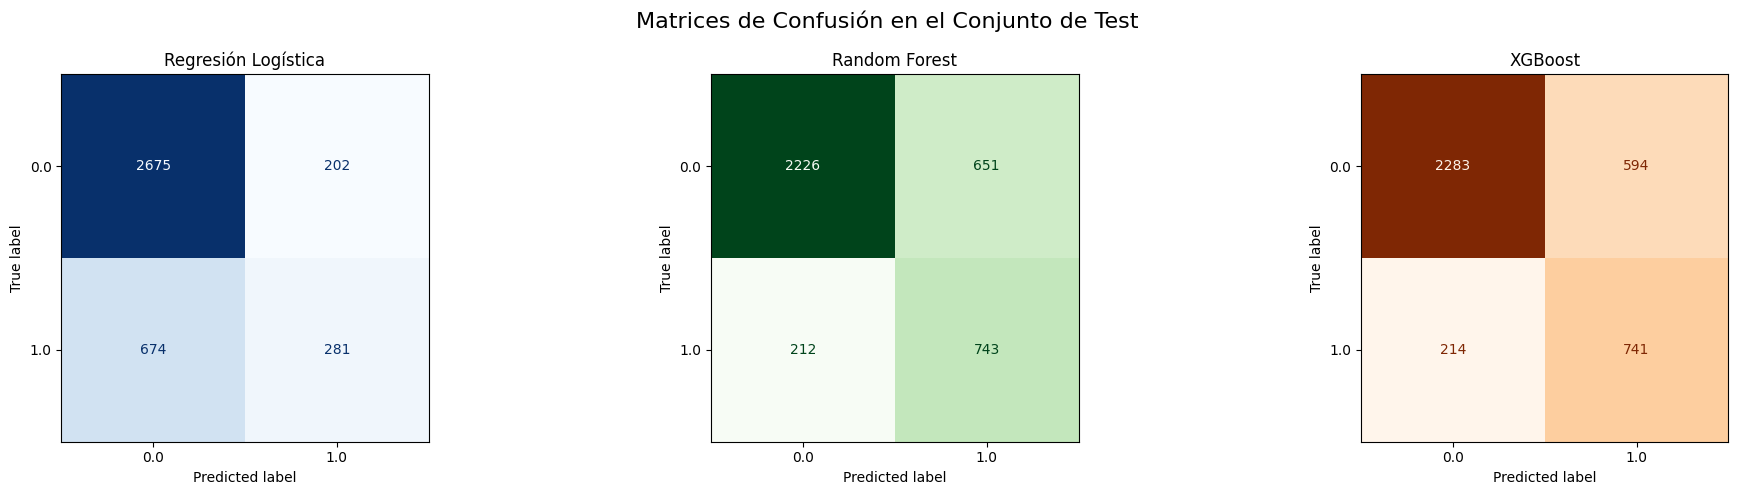

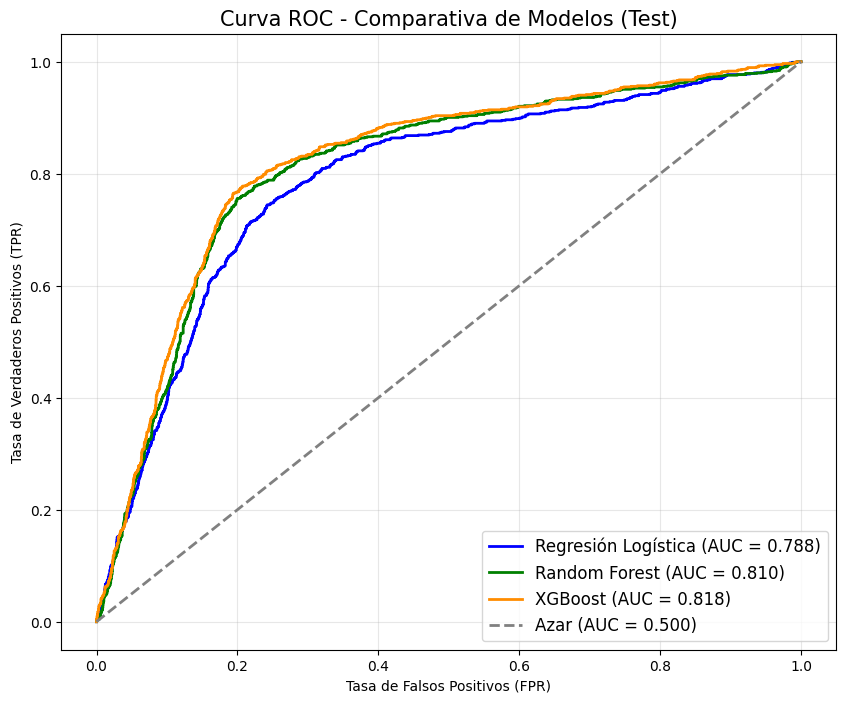

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# MÉTRICAS FINALES EN TEST (TABLA Y GRÁFICO)
y_test_pred_log = log_reg.predict(X_test)
y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_xgb = xgb_model.predict(X_test)

df_test_comparativa = pd.DataFrame([
    obtener_metricas(y_test, y_test_pred_log, 'Regresión Logística'),
    obtener_metricas(y_test, y_test_pred_rf, 'Random Forest'),
    obtener_metricas(y_test, y_test_pred_xgb, 'XGBoost')
])
df_test_comparativa.set_index('Modelo', inplace=True)

print("RESULTADOS DEFINITIVOS (CONJUNTO DE TEST)")
display(df_test_comparativa)

# LAS 3 MATRICES DE CONFUSIÓN (Lado a Lado)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Matriz 1: Regresión Logística
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_log, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Regresión Logística')

# Matriz 2: Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest')

# Matriz 3: XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_xgb, ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('XGBoost')

fig.suptitle('Matrices de Confusión en el Conjunto de Test', fontsize=16)
plt.tight_layout()
plt.show()

# CURVA ROC Y AUC (Comparativa)
# Para la curva ROC necesitamos las probabilidades, no solo la clase final
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculamos Tasa de Falsos Positivos (fpr), Tasa de Verdaderos Positivos (tpr) y AUC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Dibujamos la Curva
plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Regresión Logística (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Línea base del azar
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Azar (AUC = 0.500)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Comparativa de Modelos (Test)', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Tras el análisis, el modelo XGBoost se selecciona como el más robusto. Gracias a la ingeniería de variables y al tratamiento de nulos, hemos logrado un AUC de 0.82, lo que garantiza una alta capacidad de predicción. Este modelo permitirá a la empresa identificar preventivamente a los empleados con intención de rotar, optimizando los costes de retención de talento.